# Getting started with `fastcellstates`

This walks through the whole workflow on a real dataset: load raw UMI counts,
run `fastcellstates`, and use the resulting `Summary`: a compact generative
model, not just a label array.

Background on the model and what this fork changes: `docs/changes.md`. API
reference: the package docstrings (`help(fastcellstates)`).

In [1]:
import numpy as np
import scanpy as sc

import fastcellstates as fcs

## Load data

`fastcellstates` wants **raw UMI counts**, genes × cells: no normalisation,
no log-transform, no HVG selection. We use `scanpy.datasets.pbmc3k`, 2,700
peripheral blood cells, and only do the standard *presence* filtering (drop
genes/cells with essentially no signal), no normalisation.

In [2]:
adata = sc.datasets.pbmc3k()
sc.pp.filter_genes(adata, min_cells=3)
sc.pp.filter_cells(adata, min_genes=200)
adata

AnnData object with n_obs × n_vars = 2700 × 13714
    obs: 'n_genes'
    var: 'gene_ids', 'n_cells'

## Run it

Two things to flag:

- `adata.X` is **cells × genes**: the opposite of what `fastcellstates`
  wants. Pass `adata.X.T`, or write the `AnnData` to a `.h5ad` file and pass
  the *path* instead (`fastcellstates.run("file.h5ad")` / `io.read` transpose
  for you). See `Cluster`'s and `run`'s docstrings for this.
- `PRESETS["fast"]` is the warm-start summariser (Leiden → DM-optimal merge →
  kNN-pruned sweep): seconds, not the paper's from-singletons MCMC. It's also
  the CLI's default (`fastcellstates data.h5ad -o out/`).

In [3]:
summ = fcs.run(adata.X.T, fcs.PRESETS["fast"], genes=adata.var_names.to_numpy())
print(f"{summ.n_states} states / {summ.n_cells} cells | Theta {summ.theta:,.0f}")

26 states / 2700 cells | Theta 38,593


## The `Summary`

Not just labels: per state, a posterior Dirichlet-multinomial frequency
vector and a mixing weight.

In [4]:
summ.labels[:20]

array([ 2,  1,  2,  7,  4, 10,  8, 20, 20,  5,  1,  0,  2,  3,  6,  0,  3,
        8,  7,  2])

In [5]:
summ.weights  # mixing proportion per state, sums to 1

array([0.2137037 , 0.12592593, 0.18740741, 0.12444444, 0.05666667,
       0.05407407, 0.0537037 , 0.0562963 , 0.04296296, 0.01259259,
       0.00740741, 0.0037037 , 0.00518519, 0.00740741, 0.01259259,
       0.00037037, 0.00703704, 0.00444444, 0.00074074, 0.00111111,
       0.0062963 , 0.00037037, 0.00185185, 0.00222222, 0.00666667,
       0.00481481])

In [6]:
freq = summ.freq()  # (n_states, n_genes) posterior mean frequency per state
freq.shape, freq.sum(axis=1)  # each row sums to 1

((26, 13714),
 array([1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1., 1.,
        1., 1., 1., 1., 1., 1., 1., 1., 1.]))

## Hierarchy and markers

States merge into a tree exactly the way the agglomerative DM merge built
them: `hierarchy()` replays it as a table, `cut(k)` re-cuts it at a coarser
resolution, and `markers()` scores which genes drove each split.

In [7]:
h = summ.hierarchy()
h

,cluster_new,cluster_old,delta_LL
0,15,21,-7.994397
1,15,18,-32.196436
2,15,20,-230.953193
3,10,17,-599.55453
4,22,23,-753.721077
5,19,25,-788.316656
6,16,24,-855.172703
7,10,14,-1027.035418
8,13,15,-1082.816237
9,6,8,-1580.610234


In [8]:
# a coarser partition: merge states down to 3, without re-running anything
coarse = summ.cut(3)
np.unique(coarse, return_counts=True)

(array([0, 3, 4]), array([1460,  684,  556]))

In [9]:
m = summ.markers()  # (n_merges, n_genes); very negative = marker of that split
genes = summ.genes
for i in range(m.shape[0]):
    top = np.argsort(m[i])[:6]
    print(f"split {i} ({h.iloc[i].cluster_new} vs {h.iloc[i].cluster_old}):",
          list(genes[top]))

split 0 (15 vs 21): ['CD2', 'ATPIF1', 'SGSM2', 'OOEP', 'NEUROD2', 'U73166.2']
split 1 (15 vs 18): ['HLA-DRA', 'LETMD1', 'CD74', 'BASP1', 'TSPAN13', 'PPAPDC1B']
split 2 (15 vs 20): ['FTL', 'FTH1', 'LYZ', 'HLA-DRA', 'S100A9', 'CST3']
split 3 (10 vs 17): ['HEMK1', 'BET1', 'KIAA0196', 'MUM1', 'PDK2', 'IFI6']
split 4 (22 vs 23): ['TAF10', 'LZTS2', 'XXbac-BPG299F13.17', 'IDH2', 'USP30', 'RPS6']
split 5 (19 vs 25): ['POLE4', 'RBM3', 'THEM4', 'S1PR4', 'B2M', 'GUSB']
split 6 (16 vs 24): ['UBXN4', 'SMARCA4', 'KCNQ1OT1', 'CDC40', 'PGM2L1', 'HIST1H1B']
split 7 (10 vs 14): ['RPS12', 'RPL19', 'RPL9', 'RPS6', 'RPL13', 'RPL32']
split 8 (13 vs 15): ['GNLY', 'NKG7', 'CTSW', 'TMX2', 'HOPX', 'MOB2']
split 9 (6 vs 8): ['NKG7', 'GZMH', 'FGFBP2', 'GZMB', 'MALAT1', 'CCL5']
split 10 (6 vs 13): ['CCL5', 'IL32', 'LYAR', 'GZMM', 'B2M', 'KLRG1']
split 11 (2 vs 16): ['LTB', 'B2M', 'IL32', 'HLA-A', 'AQP3', 'IL7R']
split 12 (0 vs 2): ['MALAT1', 'RPS3A', 'RPS6', 'RPS27A', 'RPL9', 'RPS27']
split 13 (11 vs 22): ['ACTB',

## Generative use: sample / reconstruct / predict

The point of a *generative* summary: draw fresh cells, resample the input at
its own depths (a fidelity check: does the summary explain the data it was
built from?), or place new cells against the existing states.

In [10]:
new_cells = summ.sample(5, rng=0)
new_cells.shape, new_cells.dtype  # (n_genes, 5) draws

((13714, 5), dtype('int64'))

In [11]:
# reconstruction fidelity: resample every input cell at its own library size
# and compare the per-gene mean to the real data.  Keep counts sparse:
# fastcellstates accepts sparse Counts everywhere, never densify by hand
# (np.asarray() on a sparse matrix silently does NOT densify it).
counts = adata.X.T
recon = summ.reconstruct(counts, rng=0)
counts_mean = np.asarray(counts.mean(axis=1)).ravel()
rel_err = np.abs(recon.mean(1) - counts_mean) / (counts_mean + 1e-6)
f"median per-gene relative error: {np.median(rel_err):.2%}"

'median per-gene relative error: 8.37%'

In [12]:
# place held-out cells against the existing states: predict_state never
# re-fits anything, it's a pure argmax over the posterior predictive.  Using
# the first 10 training cells here as a stand-in for real held-out cells: some
# disagree with the fitted label (below), and that's expected, not a bug. The
# fitted label came from the incremental search (which also accounts for a
# cell's own presence shifting its *own* state's statistics); predict_state
# just compares against the final fixed states, so a cell near a boundary, or
# in a small state, can legitimately fall either way.
pred = summ.predict_state(counts[:, :10])
pred, summ.labels[:10]

(array([ 2,  1,  2,  7,  4, 10,  8, 20, 20,  5]),
 array([ 2,  1,  2,  7,  4, 10,  8, 20, 20,  5]))

## Seeing it: real vs. generated cells

The reconstruction check above is a number; here's the same idea as a
picture. Draw a fresh population from the `Summary` (matching the real
population size), fit the standard log-normalised PCA/UMAP embedding on the
real cells *only*, then project the generated cells into that fixed space
(`sc.tl.ingest`). Fitting the embedding jointly on real and generated cells
would let it bend to accommodate whatever the generated cells look like,
which is exactly what we want to test, not assume away. Then look at
whether the projected generated cells fall where the real ones are.

`summ.sample()` only returns counts, not which state it drew each cell from
(there's nothing to compare against for a real generative use), so we draw the
states ourselves first to be able to colour by them. We also pull in
`scanpy`'s own pbmc3k reference cell-type annotations (`pbmc3k_processed`,
matched back onto our cells by barcode) to see whether the fastcellstates
states line up with independently known biology.

In [13]:
import anndata as ad

n_gen = summ.n_cells
rng = np.random.default_rng(0)
gen_states = rng.choice(summ.n_states, size=n_gen, p=summ.weights)
gen_counts = summ.sample(n_gen, rng=0, states=gen_states)

# subset the real cells to the same genes fastcellstates actually used
# (it drops never-expressed genes internally), so real and generated line up
real_sub = adata[:, summ.genes].copy()
real_sub.obs["state"] = summ.labels.astype(str)

# scanpy's own annotated pbmc3k (a separately QC'd/filtered subset); matched
# back onto our cells by barcode, "n/a" for cells it doesn't cover
ref = sc.datasets.pbmc3k_processed()
subtype = ref.obs["louvain"].astype(str).reindex(real_sub.obs_names).fillna("n/a")
real_sub.obs["subtype"] = subtype.values

# fit the reference embedding on the real cells only; project everything
# else into it below (never refit)
sc.pp.normalize_total(real_sub, target_sum=1e4)
sc.pp.log1p(real_sub)
sc.pp.scale(real_sub, max_value=10)
sc.tl.pca(real_sub, n_comps=30)
sc.pp.neighbors(real_sub)
sc.tl.umap(real_sub)


def project_into(reference, counts, tag):
    """Embed new (G, M) counts into `reference`'s already-fitted PCA/UMAP
    space: same normalise/log/scale as the reference (using its own stored
    mean/std, not refit on the new cells), then sc.tl.ingest places the new
    points using the reference's PCA loadings and neighbour graph without
    ever moving the reference itself."""
    a = ad.AnnData(X=counts.T.astype(np.float32), var=reference.var[[]].copy())
    a.obs_names = [f"{tag}{i}" for i in range(a.n_obs)]
    sc.pp.normalize_total(a, target_sum=1e4)
    sc.pp.log1p(a)
    x = np.asarray(a.X)
    x = (x - reference.var["mean"].to_numpy()) / reference.var["std"].to_numpy()
    a.X = np.clip(x, None, 10).astype(np.float32)
    sc.tl.ingest(a, reference, embedding_method="umap")
    return a


gen = project_into(real_sub, gen_counts, "gen")

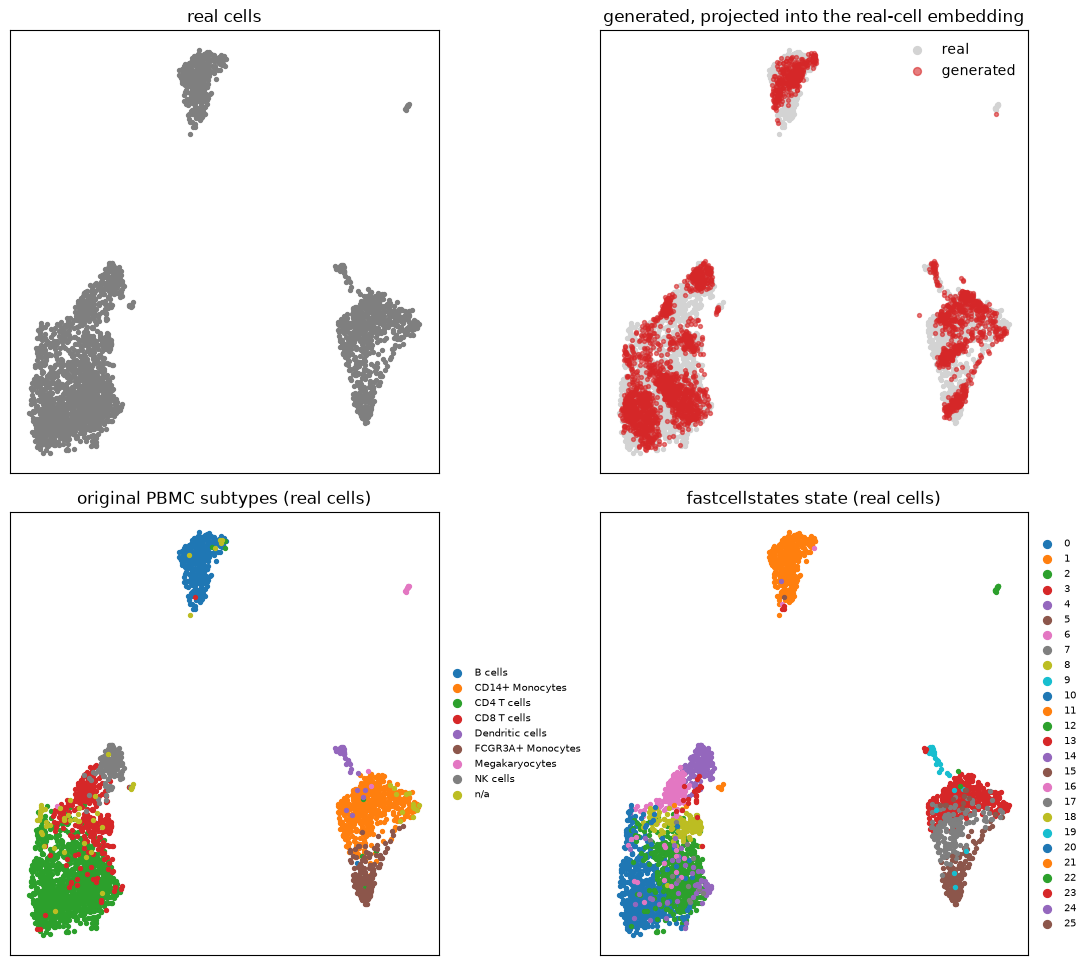

In [14]:
import matplotlib.pyplot as plt

real_xy, gen_xy = real_sub.obsm["X_umap"], gen.obsm["X_umap"]

fig, axes = plt.subplots(2, 2, figsize=(11, 10))


def scatter_by(ax, xy, labels, title, sort_key=None):
    for name in sorted(set(labels), key=sort_key):
        m = labels == name
        ax.scatter(*xy[m].T, s=8, label=str(name))
    ax.set_title(title)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(markerscale=2, frameon=False, fontsize=7,
              loc="center left", bbox_to_anchor=(1, 0.5))


axes[0, 0].scatter(*real_xy.T, s=8, c="tab:gray")
axes[0, 0].set_title("real cells")
axes[0, 0].set_xticks([])
axes[0, 0].set_yticks([])

axes[0, 1].scatter(*real_xy.T, s=8, c="lightgray", label="real")
axes[0, 1].scatter(*gen_xy.T, s=8, c="tab:red", alpha=0.6, label="generated")
axes[0, 1].set_title("generated, projected into the real-cell embedding")
axes[0, 1].set_xticks([])
axes[0, 1].set_yticks([])
axes[0, 1].legend(markerscale=2, frameon=False)

scatter_by(axes[1, 0], real_xy, real_sub.obs["subtype"].to_numpy(),
           "original PBMC subtypes (real cells)")
scatter_by(axes[1, 1], real_xy, real_sub.obs["state"].to_numpy(),
           "fastcellstates state (real cells)", sort_key=int)

fig.tight_layout()

## Choosing an estimator: posterior draw vs. plug-in mean vs. plug-in mode

`sample()`'s `estimator` argument controls how a cell's alpha is chosen, given
its state:

- `"posterior"` (used above, the default): a fresh alpha ~ Dirichlet(posterior
  params) per cell, the actual posterior predictive (eq. 18).
- `"mean"`: plug in the fixed posterior mean (eq. 20) for every cell of a
  state.
- `"mode"`: plug in the fixed posterior mode (eq. 19) instead, sparser
  (small states clip many genes to exactly 0), typically even less spread
  than `"mean"`.

Same `gen_states` and library sizes as before, only the estimator differs, so
any difference in spread below is purely the estimator's effect.

In [15]:
mean_counts = summ.sample(n_gen, rng=0, states=gen_states, estimator="mean")
mode_counts = summ.sample(n_gen, rng=0, states=gen_states, estimator="mode")

mean_ad = project_into(real_sub, mean_counts, "mean")
mode_ad = project_into(real_sub, mode_counts, "mode")

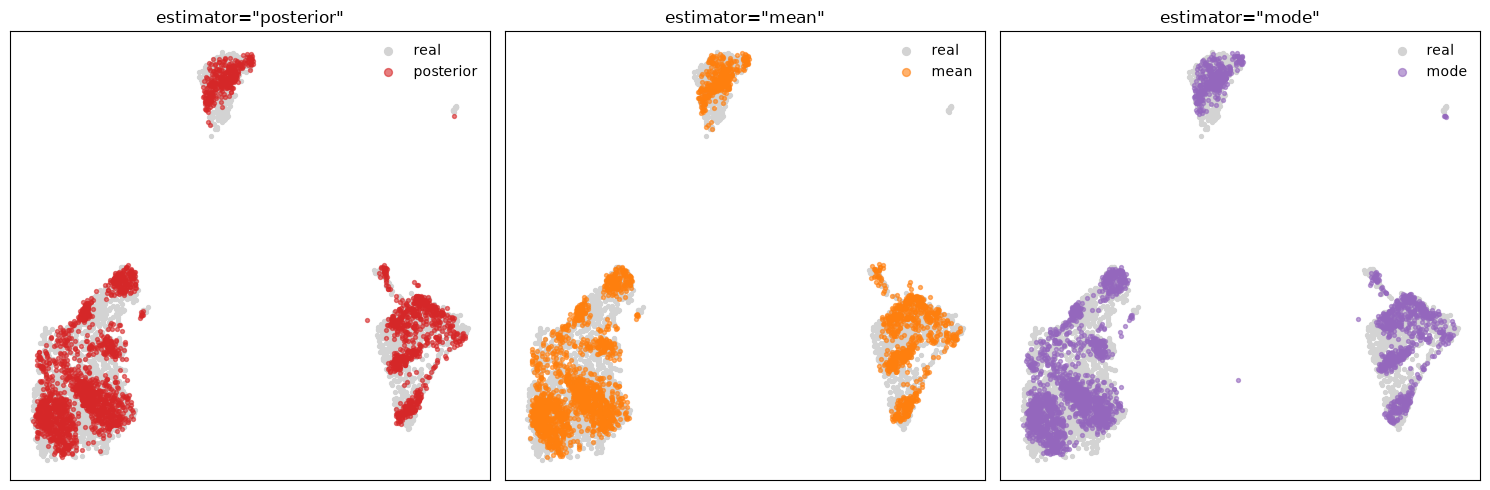

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, name, color, gen_ad in zip(
    axes,
    ["posterior", "mean", "mode"],
    ["tab:red", "tab:orange", "tab:purple"],
    [gen, mean_ad, mode_ad],
):
    ax.scatter(*real_xy.T, s=8, c="lightgray", label="real")
    ax.scatter(*gen_ad.obsm["X_umap"].T, s=8, c=color, alpha=0.6, label=name)
    ax.set_title(f'estimator="{name}"')
    ax.set_xticks([])
    ax.set_yticks([])
    ax.legend(markerscale=2, frameon=False)
fig.tight_layout()

## Tuning `fast`, and the `exact` reference

`fast` settled on 5 states above. Whether that is *right* is a separate
question, and the honest reference is the `exact` preset: the paper's
from-singletons MCMC, which only merges states it cannot statistically tell
apart.

It is slow: the next cell takes about 17 minutes on the full 2,700 cells,
and it scales poorly with cell count. On a dataset this size it is
affordable to run once as a reference; on a larger one you would tune `fast`
against `exact` on a subsample instead.

In [17]:
import time

t0 = time.time()
summ_exact = fcs.run(adata.X.T, fcs.PRESETS["exact"], genes=adata.var_names.to_numpy())
exact_secs = time.time() - t0

exact_LL = summ_exact.log_likelihood
singletons = int((np.round(summ_exact.weights * summ_exact.n_cells) == 1).sum())
print(f"exact: {summ_exact.n_states} states ({singletons} singletons), "
      f"Theta {summ_exact.theta:,.0f}, {exact_secs:.0f} s, logL {exact_LL:,.0f}")

exact: 345 states (128 singletons), Theta 16,384, 1086 s, logL -43,366,849


### The resolution knob

`fast`'s speed comes from starting the search already partitioned: a Leiden
over-clustering of the cell graph (`PRESETS["fast"]` uses CPM), which the
DM-optimal merge then coarsens back down. The Leiden `resolution` sets how
fine that starting point is. It only has to avoid *under*-segmenting: the
merge cannot recover a distinction Leiden never made, but it happily drops
ones that do not pay their way.

We sweep `resolution` at a *fixed* Theta (the value `exact` converged to) so
the log-likelihoods compare directly, and score each partition against the
`exact` labels with the adjusted Rand index. At `resolution=1.0` CPM shatters
this graph completely (`n_init` = every cell), so that row is effectively a
singleton start run through the `fast` path: merge and sweep, but no MCMC.

In [18]:
import copy

import scipy.sparse as sp
from sklearn.metrics import adjusted_rand_score

from fastcellstates.graph import cell_knn
from fastcellstates.partition import over_partition

Xc = sp.csc_matrix(adata.X.T)
knn = cell_knn(Xc, k=30, metric="pca", n_pcs=50)

resolutions = [0.02, 0.05, 0.1, 0.2, 0.5, 1.0]
rows = []
labels_at = {}
for res in resolutions:
    n_init = int(over_partition(knn, algorithm="cpm", resolution=res, seed=1).max()) + 1

    cfg = copy.deepcopy(fcs.PRESETS["fast"])
    cfg.init.resolution = res
    cfg.model = fcs.ModelCfg(theta_method="fixed", theta=summ_exact.theta)

    t0 = time.time()
    s = fcs.run(adata.X.T, cfg, genes=adata.var_names.to_numpy())
    secs = time.time() - t0

    labels_at[res] = s.labels
    rows.append(dict(resolution=res, n_init=n_init, n_states=s.n_states,
                     seconds=round(secs, 1), logL=round(s.log_likelihood),
                     ari_vs_exact=round(adjusted_rand_score(summ_exact.labels, s.labels), 3)))

import pandas as pd

sweep = pd.DataFrame(rows).set_index("resolution")
sweep

,n_init,n_states,seconds,logL,ari_vs_exact
resolution,,,,,
0.02,8,12,1.7,-43417107,0.612
0.05,42,20,3.0,-43405955,0.656
0.10,103,23,2.4,-43404527,0.685
0.20,235,56,4.6,-43388734,0.772
0.50,626,138,2.2,-43377276,0.853
1.00,2700,367,9.7,-43368385,0.916


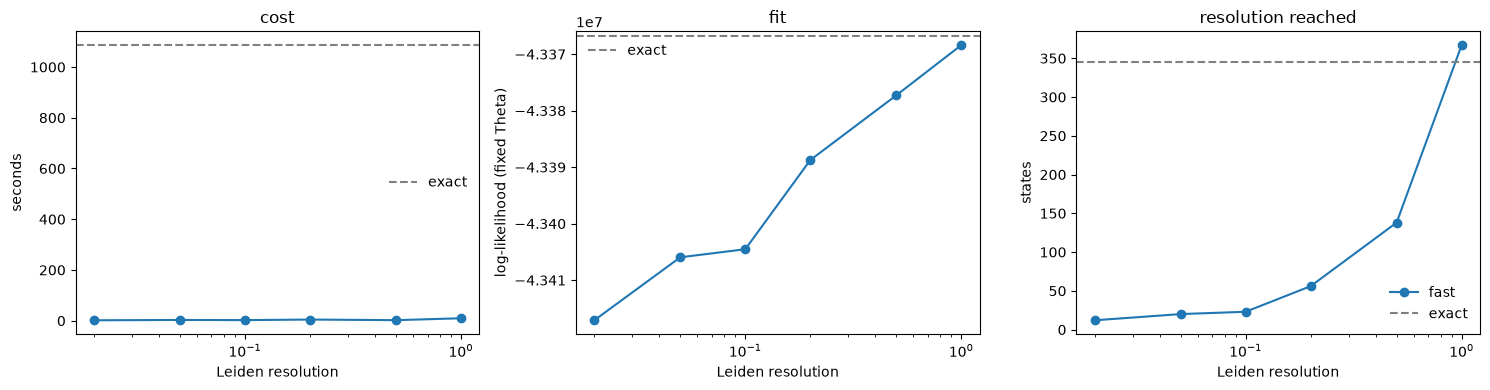

In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

axes[0].plot(sweep.index, sweep.seconds, "o-")
axes[0].axhline(exact_secs, ls="--", c="gray", label="exact")
axes[0].set_ylabel("seconds")
axes[0].set_title("cost")

axes[1].plot(sweep.index, sweep.logL, "o-")
axes[1].axhline(exact_LL, ls="--", c="gray", label="exact")
axes[1].set_ylabel("log-likelihood (fixed Theta)")
axes[1].set_title("fit")

axes[2].plot(sweep.index, sweep.n_states, "o-", label="fast")
axes[2].axhline(summ_exact.n_states, ls="--", c="gray", label="exact")
axes[2].set_ylabel("states")
axes[2].set_title("resolution reached")

for ax in axes:
    ax.set_xscale("log")
    ax.set_xlabel("Leiden resolution")
    ax.legend(frameon=False)
fig.tight_layout()

### What each resolution converges to

The same real-cell UMAP as before, coloured by the `fast` state each cell
lands in at four resolutions. Low resolution collapses distinct populations
together; raising it splits them back out, up to the point where the merge
stops finding a reason to keep them apart.

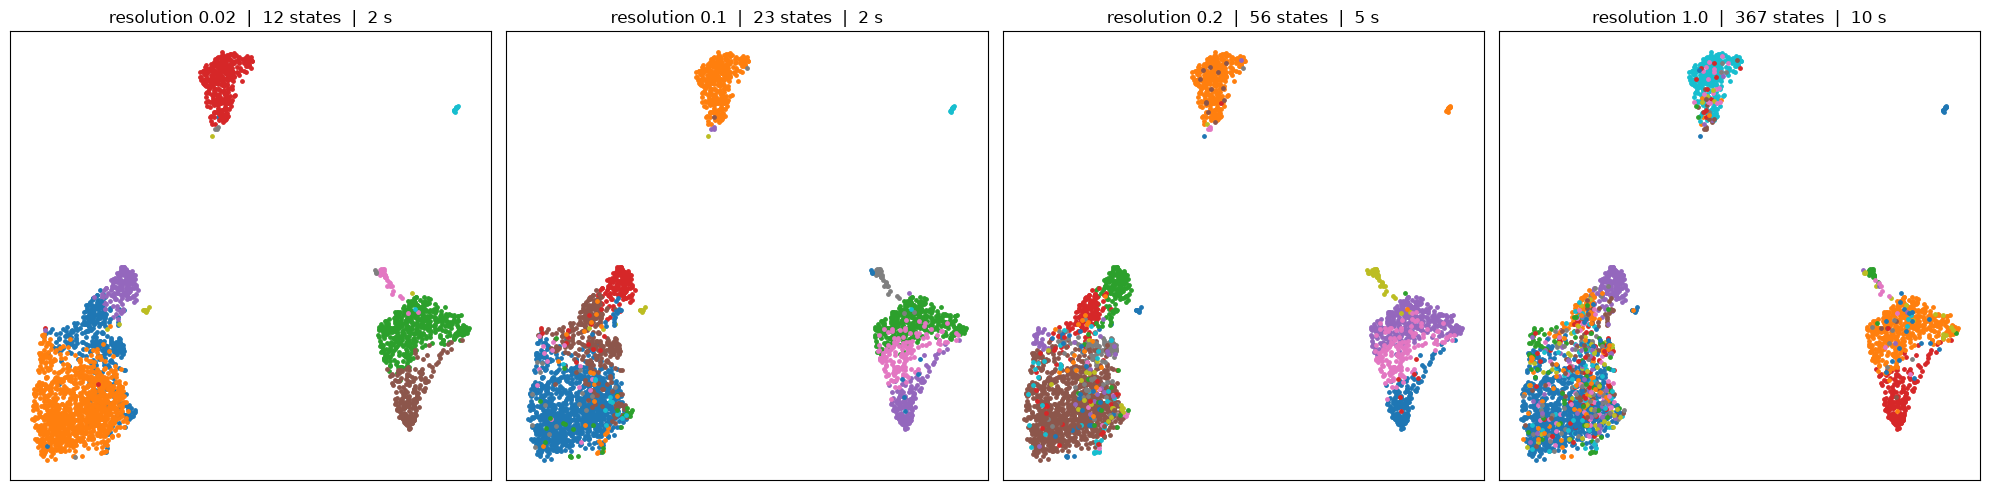

In [20]:
show = [0.02, 0.1, 0.2, 1.0]
fig, axes = plt.subplots(1, len(show), figsize=(5 * len(show), 5))
for ax, res in zip(axes, show):
    lab = labels_at[res]
    for k in range(lab.max() + 1):
        m = lab == k
        ax.scatter(*real_xy[m].T, s=6)
    r = sweep.loc[res]
    ax.set_title(f"resolution {res}  |  {int(r.n_states)} states  |  {r.seconds:.0f} s")
    ax.set_xticks([])
    ax.set_yticks([])
fig.tight_layout()

Two things stand out. `fast`'s runtime barely moves across the whole sweep, a
few seconds either way: the DM-optimal merge dominates and it is cheap, so
there is little reason to keep `resolution` low. And the fit keeps improving
right up to the singleton start, which lands within 0.01% of `exact`'s
log-likelihood, at ARI 0.92, in about 8 seconds against 17 minutes. The merge
recovers most of what matters even from singletons; `exact`'s MCMC then
refines it (here a slightly higher likelihood, and a defensible 345 states
rather than 367).

Practical read: the default `resolution=0.1` is a deliberately coarse, fast
summary. When you want finer resolution, raise it (0.5 or above) for a few
extra seconds rather than reaching for `exact`. Keep `exact` for when you
need the most defensible state count or the last fraction of fit.

## Save / load

`Summary` round-trips through a single `.npz`: everything above works again
after loading, no access to the original data needed.

In [21]:
summ.save("pbmc3k_summary.npz")
reloaded = fcs.Summary.load("pbmc3k_summary.npz")
reloaded.n_states, reloaded.n_cells

(26, 2700)

## Plotting (optional, needs `pip install 'fastcellstates[plot]'`)

Dendrogram of the state hierarchy; loads lazily, so nothing above needed it.

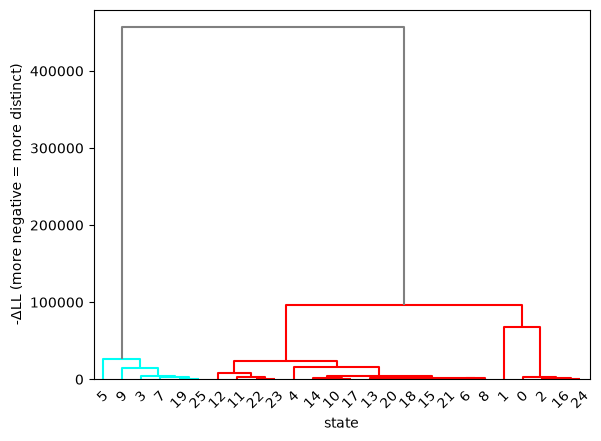

In [22]:
import matplotlib.pyplot as plt

fcs.plot_hierarchy_scipy(h)
plt.xlabel("state")
plt.ylabel("-ΔLL (more negative = more distinct)")
plt.show()